# Talep Tahmini ve Dinamik Stok Optimizasyonu

Bu notebook, veri keşfinden model eğitimine kadar olan analiz adımlarını içerir.
Panelin kullandığı tahmin ve metrik dosyaları `src/build_artifacts.py` ile üretilir.

**Veri:** Kaggle — Store Item Demand Forecasting Challenge (10 mağaza x 50 urun, 2013-2017, 913.000 satir)

## 1. Veriyi tanima


In [5]:
import pandas as pd
df= pd.read_csv("../data/train.csv")
df.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [6]:
print("Veri Boyutu", df.shape)
df.info()

Veri Boyutu (913000, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   date    913000 non-null  object
 1   store   913000 non-null  int64 
 2   item    913000 non-null  int64 
 3   sales   913000 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 27.9+ MB


In [7]:
df['date']= pd.to_datetime(df['date']) # dtype objectti datetime çeviriyoruz.

In [8]:
print("Satış İstatistikleri")
print(df['sales'].describe()) # satışların temel istatistikleri


Satış İstatistikleri
count    913000.000000
mean         52.250287
std          28.801144
min           0.000000
25%          30.000000
50%          47.000000
75%          70.000000
max         231.000000
Name: sales, dtype: float64


In [13]:
print(f"Başlangıç tarihi: {df['date'].min()}")
print(f"Bitiş tarihi: {df['date'].max()}")

Başlangıç tarihi: 2013-01-01 00:00:00
Bitiş tarihi: 2017-12-31 00:00:00


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

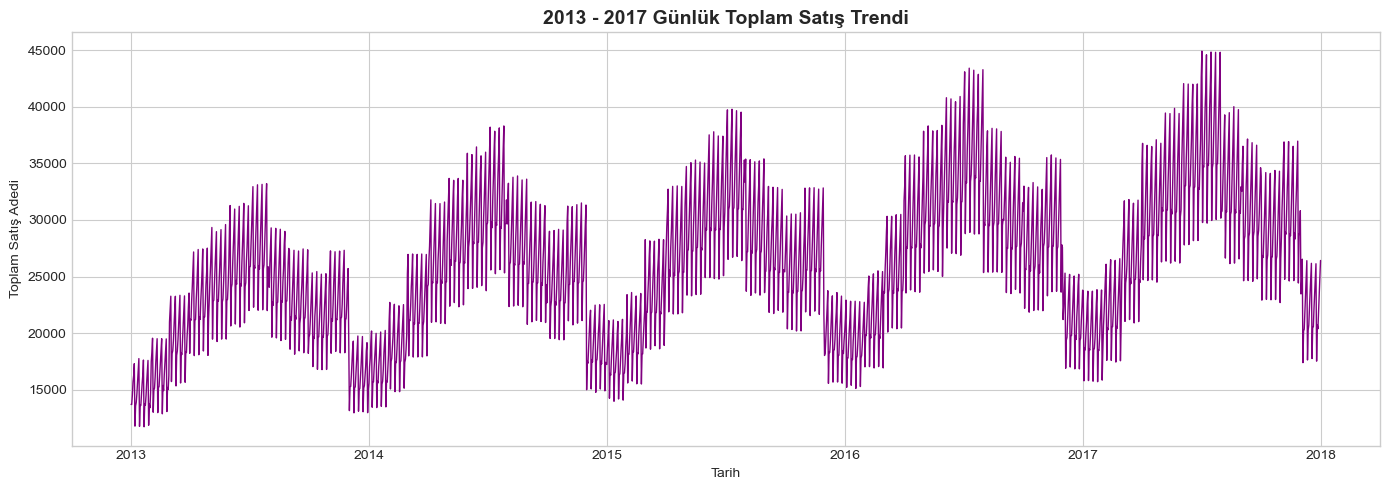

In [21]:
plt.style.use('seaborn-v0_8-whitegrid') # görselleştirme stili
daily_total= df.groupby('date')['sales'].sum().reset_index()
plt.figure(figsize=(14,5))
plt.plot(daily_total['date'],daily_total['sales'], color='purple', linewidth=1)
plt.title('2013 - 2017 Günlük Toplam Satış Trendi', fontsize=14, fontweight='bold')
plt.xlabel('Tarih')
plt.ylabel('Toplam Satış Adedi')
plt.tight_layout()
plt.show()

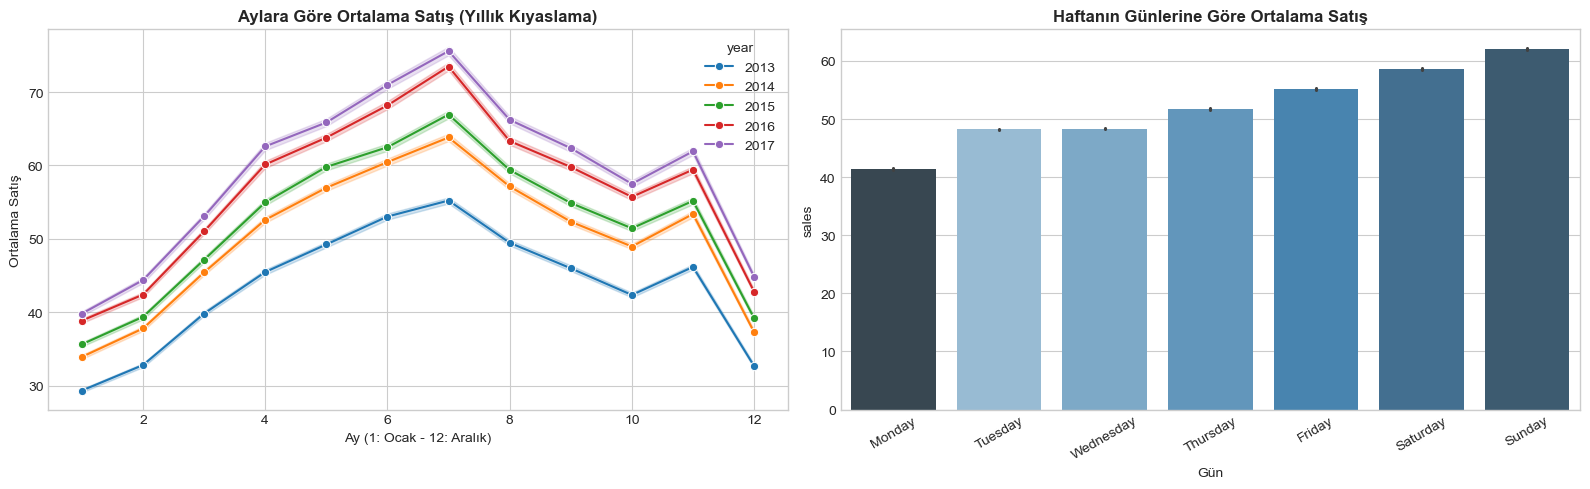

In [29]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day_name'] = df['date'].dt.day_name()
df['is_weekend'] = df['date'].dt.dayofweek >= 5 #tarihten zaman bileşenlerini ürettim
fig, axes = plt.subplots (1,2, figsize= (16,5)) #grafik çizdirdim
sns.lineplot(data=df, x='month', y='sales', hue='year', marker='o', palette='tab10', ax=axes[0])
axes[0].set_title('Aylara Göre Ortalama Satış (Yıllık Kıyaslama)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Ay (1: Ocak - 12: Aralık)')
axes[0].set_ylabel('Ortalama Satış') # >> aylara göre ortalama satış
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.barplot(data=df, x='day_name', y='sales', order=day_order, hue='day_name', palette='Blues_d', 
    legend=False, 
    ax=axes[1])
axes[1].set_title('Haftanın Günlerine Göre Ortalama Satış', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Gün')
axes[1].tick_params(axis='x', rotation=30) # >> haftaların ügnlerine göre ort satış

plt.tight_layout()
plt.show()

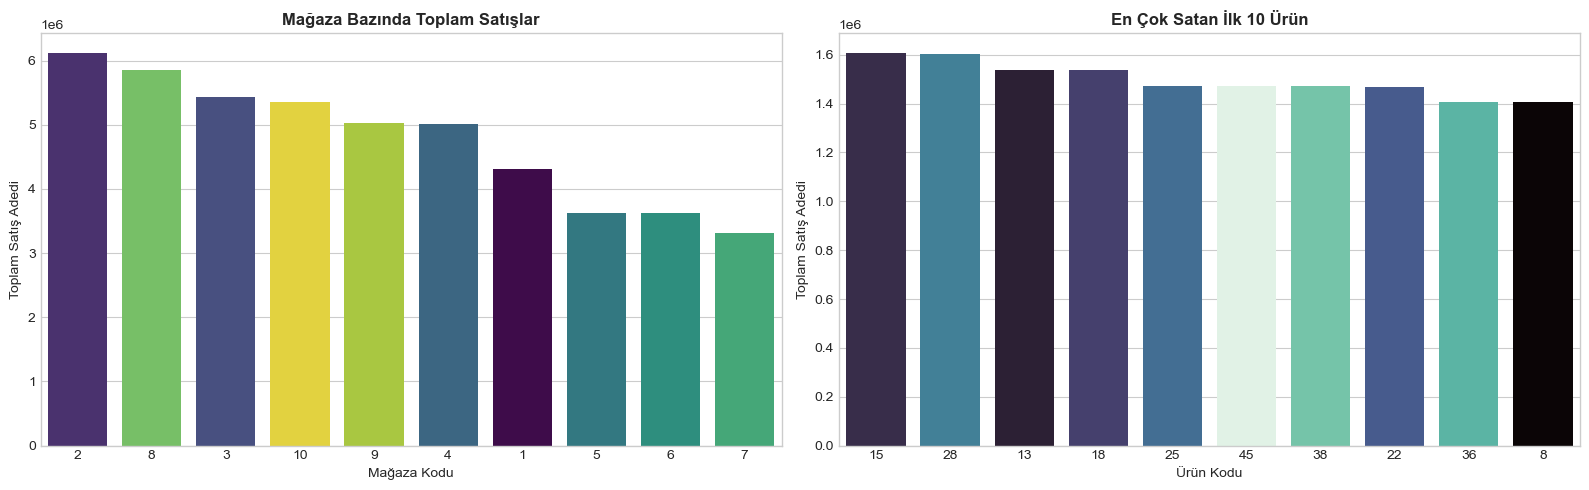

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
# 1. Mağazalara göre toplam satış
store_sales = df.groupby('store')['sales'].sum().sort_values(ascending=False).reset_index()
sns.barplot(
    data=store_sales, 
    x='store', 
    y='sales', 
    order=store_sales['store'], 
    hue='store', 
    palette='viridis', 
    legend=False, 
    ax=axes[0]
)
axes[0].set_title('Mağaza Bazında Toplam Satışlar', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Mağaza Kodu')
axes[0].set_ylabel('Toplam Satış Adedi')

# 2. En çok satan ilk 10 ürün
top_items = df.groupby('item')['sales'].sum().nlargest(10).reset_index()
sns.barplot(
    data=top_items, 
    x='item', 
    y='sales', 
    order=top_items['item'], 
    hue='item', 
    palette='mako', 
    legend=False, 
    ax=axes[1]
)
axes[1].set_title('En Çok Satan İlk 10 Ürün', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Ürün Kodu')
axes[1].set_ylabel('Toplam Satış Adedi')

plt.tight_layout()
plt.show()


## 2. Oznitelik muhendisligi

Gecikme (lag) ve hareketli istatistikler `sales_lag_7` uzerinden hesaplanir; boylece model
tahmin anindaki satisi hicbir zaman gormez.


In [32]:
# Veriyi tarih, mağaza ve ürün sırasına göre sıralayalım (Lag hesaplamaları için şart)
df = df.sort_values(by=['store', 'item', 'date']).reset_index(drop=True)

# Ekstra zaman değişkenleri
df['day_of_year'] = df['date'].dt.dayofyear
df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)
df['quarter'] = df['date'].dt.quarter
df['day_of_month'] = df['date'].dt.day
lags = [7, 14, 21, 30, 60, 90]

for lag in lags:
    # Her mağaza ve ürün grubuna özel shift (gecikme) uygula
    df[f'sales_lag_{lag}'] = df.groupby(['store', 'item'])['sales'].shift(lag) #Her mağaza ve ürün ikilisini kendi içinde izole bir zaman tüneli gibi düşün. 7 gün önceki satışı alırken sadece o mağazanın o üründeki kendi geçmişine bak.

print("Lag değişkenleri başarıyla üretildi.")

Lag değişkenleri başarıyla üretildi.


In [33]:
# 7 gün önceki satışın üzerinden geriye dönük hareketli ortalamalar
# (Böylece model geleceği görmeden geçmişin ortalama hızını öğrenir)

windows = [7, 14, 30, 60]

for window in windows:
    df[f'sales_roll_mean_{window}'] = df.groupby(['store', 'item'])['sales_lag_7'].transform(
        lambda x: x.rolling(window=window).mean()
    )
    df[f'sales_roll_std_{window}'] = df.groupby(['store', 'item'])['sales_lag_7'].transform(
        lambda x: x.rolling(window=window).std()
    )

print("Rolling (Hareketli Ortalama ve Std) değişkenleri başarıyla üretildi.")

Rolling (Hareketli Ortalama ve Std) değişkenleri başarıyla üretildi.


In [34]:
# NaN oluşan ilk dönem satırlarını temizle
df_model = df.dropna().reset_index(drop=True)

print("Ham Veri Satır Sayısı:  ", df.shape[0])
print("Modele Hazır Satır Sayısı:", df_model.shape[0])
print("\nYeni Sütun Sayısı:       ", df_model.shape[1])
print("\n--- İlk 5 Satır ---")
df_model.head()

Ham Veri Satır Sayısı:   913000
Modele Hazır Satır Sayısı: 868000

Yeni Sütun Sayısı:        26

--- İlk 5 Satır ---


,date,store,item,sales,year,month,day_name,is_weekend,day_of_year,week_of_year,...,sales_lag_60,sales_lag_90,sales_roll_mean_7,sales_roll_std_7,sales_roll_mean_14,sales_roll_std_14,sales_roll_mean_30,sales_roll_std_30,sales_roll_mean_60,sales_roll_std_60
0,2013-04-01,1,1,11,2013,4,Monday,False,91,14,...,13.0,13.0,17.714286,3.199702,15.571429,4.200994,14.233333,4.040172,13.000000,3.737125
1,2013-04-02,1,1,19,2013,4,Tuesday,False,92,14,...,11.0,11.0,17.285714,3.199702,15.714286,4.177385,14.400000,4.005169,13.033333,3.755072
2,2013-04-03,1,1,24,2013,4,Wednesday,False,93,14,...,21.0,14.0,16.857143,3.848314,15.571429,4.309458,14.533333,3.812261,13.016667,3.761949
3,2013-04-04,1,1,18,2013,4,Thursday,False,94,14,...,15.0,13.0,16.285714,4.111540,15.785714,4.079566,14.666667,3.679705,13.033333,3.759583
4,2013-04-05,1,1,19,2013,4,Friday,False,95,14,...,14.0,10.0,15.714286,3.592320,16.000000,4.057282,14.933333,3.542192,13.133333,3.784297



## 3. Model egitimi ve degerlendirme

Bolme zaman bazlidir: 2013-2016 egitim, 2017 test. Rastgele bolme zaman serisinde
sizintiya yol acar.


In [40]:
import lightgbm as lgb
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Metin ve boolean içeren sütunları sayısal/kategorik tipe dönüştür
df_model['is_weekend'] = df_model['is_weekend'].astype(int)
df_model['day_of_week_num'] = df_model['date'].dt.dayofweek

# Modele girmeyecek gereksiz metin/tarih sütunlarını belirle
drop_cols = ['date', 'sales', 'day_name']
features = [col for col in df_model.columns if col not in drop_cols]
target = 'sales'

# 2. Zamana Dayalı Train / Test Bölmesi (2013-2016 Train, 2017 Test)
train_df = df_model[df_model['date'] < '2017-01-01']
test_df = df_model[df_model['date'] >= '2017-01-01']

X_train, y_train = train_df[features], train_df[target]
X_test, y_test = test_df[features], test_df[target]

print(f"Eğitim Seti Boyutu: {X_train.shape}")
print(f"Test Seti Boyutu:   {X_test.shape}")

# 3. LightGBM Modelini Kur ve Eğit
model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=31,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# 4. 2017 Yılı İçin Tahmin Yap
test_df = test_df.copy()
test_df['prediction'] = model.predict(X_test)

# Negatif tahmin varsa sıfıra eşitle (satış eksi olamaz)
test_df['prediction'] = test_df['prediction'].clip(lower=0)

# 5. Hata Metriklerinin Hesaplanması
mae = mean_absolute_error(test_df['sales'], test_df['prediction'])
rmse = np.sqrt(mean_squared_error(test_df['sales'], test_df['prediction']))
wape = (np.sum(np.abs(test_df['sales'] - test_df['prediction'])) / np.sum(test_df['sales'])) * 100

print("\n--- Model Performans Sonuçları (2017 Test Seti) ---")
print(f"MAE  (Ortalama Mutlak Hata): {mae:.2f} adet")
print(f"RMSE (Kök Ortalama Kare Hata): {rmse:.2f} adet")
print(f"WAPE (Ağırlıklı Hata Payı):   %{wape:.2f}")

Eğitim Seti Boyutu: (685500, 24)
Test Seti Boyutu:   (182500, 24)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010207 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3567
[LightGBM] [Info] Number of data points in the train set: 685500, number of used features: 24
[LightGBM] [Info] Start training from score 51.698131

--- Model Performans Sonuçları (2017 Test Seti) ---
MAE  (Ortalama Mutlak Hata): 6.12 adet
RMSE (Kök Ortalama Kare Hata): 7.95 adet
WAPE (Ağırlıklı Hata Payı):   %10.41


/var/folders/80/f1ccy2qd4qlc3z2xxm15rfq40000gn/T/ipykernel_37291/1815449997.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance.head(15), x='Importance', y='Feature', palette='magma')


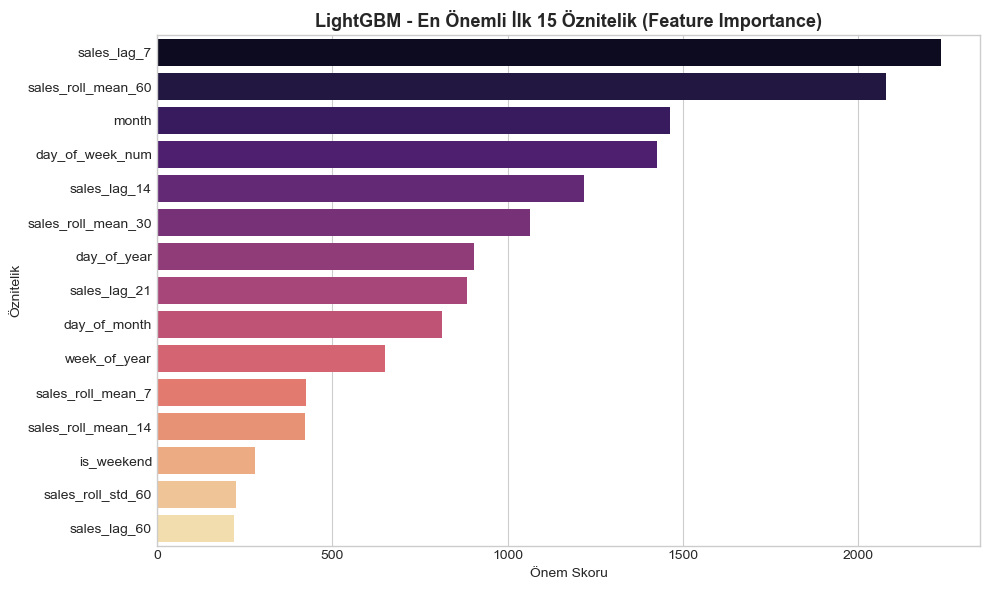

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Değişken önem düzeylerini al
importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# En önemli ilk 15 değişkeni çizdir
plt.figure(figsize=(10, 6))
sns.barplot(data=importance.head(15), x='Importance', y='Feature', palette='magma')
plt.title('LightGBM - En Önemli İlk 15 Öznitelik (Feature Importance)', fontsize=13, fontweight='bold')
plt.xlabel('Önem Skoru')
plt.ylabel('Öznitelik')
plt.tight_layout()
plt.show()


## 4. Referans yontemlerle karsilastirma

Bir WAPE degeri tek basina anlam tasimaz; neyi yendigi gosterilmelidir.


In [ ]:
!python ../src/baselines.py



## 5. Stok politikasi parametreleri

Tahmin hatasinin standart sapmasindan guvenlik stogu ve yeniden siparis noktasi turetilir.


In [43]:
# 1. Hataların (Residuals) Hesaplanması
test_df['error'] = test_df['sales'] - test_df['prediction']

# 2. Her mağaza ve ürün grubu için tahmin hatasının standart sapması
error_std = test_df.groupby(['store', 'item'])['error'].std().reset_index()
error_std.rename(columns={'error': 'error_std'}, inplace=True)

# 3. Parametrelerin Tanımlanması
service_level_z = 1.65  # %95 Hizmet Seviyesi (Z skoru)
lead_time_days = 3      # Tedarik süresi: 3 gün

# 4. Güvenlik Stoğu Hesabı
error_std['safety_stock'] = np.ceil(service_level_z * error_std['error_std'] * np.sqrt(lead_time_days)).astype(int)

# 5. Sonuçları test tablosu ile birleştir
inventory_df = pd.merge(test_df, error_std[['store', 'item', 'safety_stock']], on=['store', 'item'], how='left')

# Yeniden Sipariş Noktası (ROP) = (Günlük Tahmin * Lead Time) + Safety Stock
inventory_df['reorder_point'] = np.ceil((inventory_df['prediction'] * lead_time_days) + inventory_df['safety_stock']).astype(int)

# Örnek ilk 5 satırı inceleyelim
print("--- Stok Optimizasyonu Çıktıları (İlk 5 Satır) ---")
inventory_df[['date', 'store', 'item', 'sales', 'prediction', 'safety_stock', 'reorder_point']].head()

--- Stok Optimizasyonu Çıktıları (İlk 5 Satır) ---


,date,store,item,sales,prediction,safety_stock,reorder_point
0,2017-01-01,1,1,19,19.201019,14,72
1,2017-01-02,1,1,15,12.987019,14,53
2,2017-01-03,1,1,10,14.724111,14,59
3,2017-01-04,1,1,16,14.077295,14,57
4,2017-01-05,1,1,14,15.745226,14,62



## 6. Model ve veri ciktilarini kaydetme

Panelin kullandigi dosyalar `src/build_artifacts.py` tarafindan uretilir:

```bash
python src/build_artifacts.py
```


In [ ]:
import joblib
from pathlib import Path

Path('../models').mkdir(exist_ok=True)
joblib.dump(model, '../models/lgb_demand_model.pkl')
print('Model kaydedildi.')
